Random Forest - MAE: 0.13101288285711257, MSE: 0.03265215317967408, R²: 0.6122596333900467


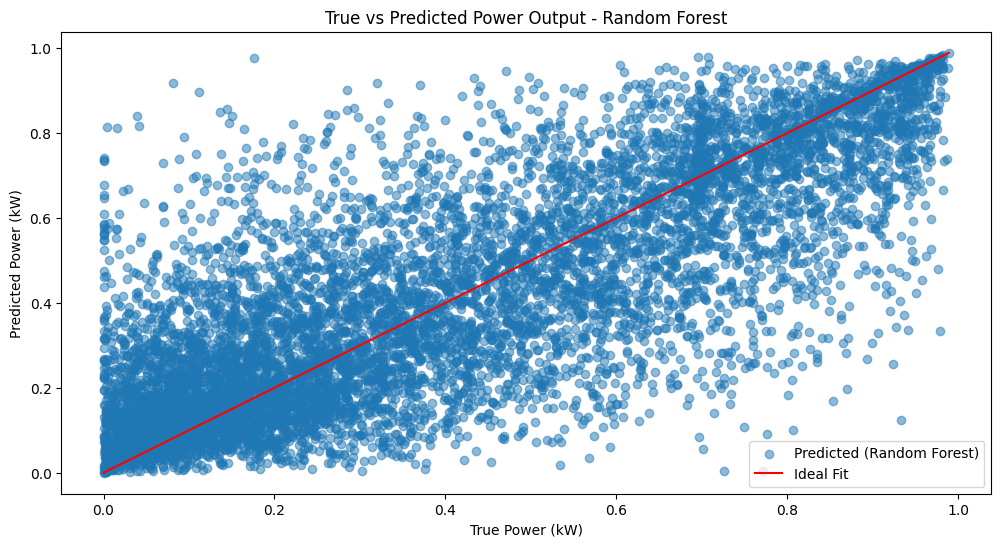

In [2]:

data['Time'] = pd.to_datetime(data['Time'])
data['hour'] = data['Time'].dt.hour
data['day_of_week'] = data['Time'].dt.dayofweek
data['month'] = data['Time'].dt.month

features = [
    'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 
    'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 
    'winddirection_100m', 'windgusts_10m', 'hour', 'day_of_week', 'month'
]
target = 'Power'

X = data[features]
y = data[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=2, random_state=42)
rf_regressor.fit(X_train_scaled, y_train_scaled.flatten())

# Predict with Random Forest
y_pred_rf = rf_regressor.predict(X_test_scaled)

# Calculate performance metrics for Random Forest
mae_rf = mean_absolute_error(y_test_scaled, y_pred_rf)
mse_rf = mean_squared_error(y_test_scaled, y_pred_rf)
r2_rf = r2_score(y_test_scaled, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf}, MSE: {mse_rf}, R²: {r2_rf}")

# Plotting results for Random Forest
results_rf = pd.DataFrame({
    'True Power (kW)': y_test.values,
    'Predicted Power (kW) - Random Forest': scaler_y.inverse_transform(y_pred_rf.reshape(-1, 1)).flatten()
})

plt.figure(figsize=(12, 6))
plt.scatter(results_rf['True Power (kW)'], results_rf['Predicted Power (kW) - Random Forest'], alpha=0.5, label='Predicted (Random Forest)')
plt.plot([results_rf['True Power (kW)'].min(), results_rf['True Power (kW)'].max()],
         [results_rf['True Power (kW)'].min(), results_rf['True Power (kW)'].max()],
         color='red', label='Ideal Fit')
plt.title('True vs Predicted Power Output - Random Forest')
plt.xlabel('True Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.legend()
plt.show()


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('Location1.csv')
data.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793
